# Showcase: a monthly-rebalanced swap book, from passing in the library to the tearsheet

**The strategy, and how "1mm 10y equivalent" is read.** A swap book starts empty. Once a month a *ladder hedge* action measures the book's **delta ladder**
(currency per +1bp in each tenor bucket, a plain `dict[str, float]`) and trades USD SOFR OIS swaps at **2Y, 5Y, 10Y and 30Y** (receive-fixed by default; `side` is a per-action
term) so that the ladder equals the target by weighted least squares.

* **Target: a total book dollar delta of 1,000,000 per bp, expressed as a 10y-equivalent target ladder** `{"10Y": 1_000_000}`, every other bucket 0 (configurable).
* **Dollar delta** is the PV change for +1bp in rates, so a payer is positive and a receiver negative. A positive target is reached by *paying* fixed: the hedge set is receive-fixed
  swaps traded at a negative quantity. Each hedge leg is one unit of a 1mm swap; a quantity of -1,234 is 1.23bn of notional.
* Positions age between rebalances (their buckets drift with time and rates), so the deviation the next rebalance closes is real.
* One instrument spec, `usd_sofr_ois`, plus per-action **terms**. No per-tenor or per-direction instrument definitions exist anywhere in this notebook.

What this notebook shows, in order: (1) passing the pricing library in by binding, (2) market data as snapshots, (3) the engine, (4) signals, (5) the trigger and action,
(6) results with the tearsheet, (7) assertions that must hold, (8) the same base configuration under a second library and a dependency-free reference stack, tied out.

In [4]:
import sys
sys.path.append(r"C:\Users\chris\clee\gsquant-temp-claude")

In [5]:
import copy
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from IPython.display import Image, display

sys.path.insert(0, "tests")  # the test-support market-data providers: they read data/fixtures and emit plain snapshots, importing no pricing library

import pricebt
import pricebt.contrib.rateslib as adapter  # the library-specific step is naming the adapter: pricebt itself never imports a pricing library
from pricebt import api
from support.curves import CurveStore

warnings.filterwarnings("ignore", category=FutureWarning)
pd.options.display.float_format = "{:,.2f}".format
pd.options.display.width = 200
plt.rcParams.update({"figure.figsize": (11, 3.4), "axes.grid": True, "grid.alpha": 0.3})
NY = "America/New_York"
OUT = Path("results/showcase")
OUT.mkdir(parents=True, exist_ok=True)
print("pricebt", pricebt.__file__)

ModuleNotFoundError: No module named 'pricebt.contrib'

## 1. Passing in the external library

An **instrument spec** is defined once: an asset class, a `factory` (the adapter's kit: a factory plus its default bindings) and a `conventions` block. The conventions are
*data*: pricebt passes them to the library untouched and hashes them into the run manifest, so two libraries can be given the very same block.

In [2]:
CONVENTIONS = {**adapter.USD_SOFR_OIS_CONVENTIONS, "calendar": "usd_fed"}  # the calendar is a NAME in the snapshots the provider emits
INSTRUMENTS = {"usd_sofr_ois": {"asset_class": "swap", "factory": "pricebt.contrib.rateslib:swap", "conventions": CONVENTIONS}}
print(yaml.safe_dump({"instruments": INSTRUMENTS}, sort_keys=False))

instruments:
  usd_sofr_ois:
    asset_class: swap
    factory: pricebt.contrib.rateslib:swap
    conventions:
      calendar: usd_fed
      spot_lag_days: 2
      day_count: act360
      frequency: annual
      business_day_convention: modified_following
      payment_lag_days: 2
      compounding: daily_compounded
      stub: short_front
      end_of_month: false
      fixing_lag_days: 1
      time_accrual: lump



The adapter ships a **default binding block**: for each name the `swap` schema requires (`value`, `dv01`, `gamma`, `rate`, `delta_ladder` and the four layers) it says which
method of the library's object to call and with exactly which arguments. Nothing is looked up by name and nothing is injected: `@ctx` is one of the few references pricebt
resolves (`@pricer`, `@ctx`, `@instrument`, `@terms.<name>`, `@state.<key>`), and a ladder declares the `keys` it returns and a `reduce`r to a plain dict.

In [3]:
print(yaml.safe_dump(dict(adapter.SWAP_BIND), sort_keys=False))

value:
  target:
    method: value
  kwargs:
    ctx: '@ctx'
dv01:
  target:
    method: dv01
  kwargs:
    ctx: '@ctx'
    tenors:
    - 3M
    - 6M
    - 1Y
    - 2Y
    - 3Y
    - 5Y
    - 7Y
    - 10Y
    - 15Y
    - 20Y
    - 30Y
gamma:
  target:
    method: gamma
  kwargs:
    ctx: '@ctx'
    tenors:
    - 3M
    - 6M
    - 1Y
    - 2Y
    - 3Y
    - 5Y
    - 7Y
    - 10Y
    - 15Y
    - 20Y
    - 30Y
rate:
  target:
    method: rate
  kwargs:
    ctx: '@ctx'
delta_ladder:
  target:
    method: delta_ladder
  kwargs:
    ctx: '@ctx'
    tenors:
    - 3M
    - 6M
    - 1Y
    - 2Y
    - 3Y
    - 5Y
    - 7Y
    - 10Y
    - 15Y
    - 20Y
    - 30Y
  keys:
  - 3M
  - 6M
  - 1Y
  - 2Y
  - 3Y
  - 5Y
  - 7Y
  - 10Y
  - 15Y
  - 20Y
  - 30Y
  reduce: dict_of_floats
carry:
  target:
    method: carry
  kwargs:
    ctx: '@ctx'
roll:
  target:
    method: roll
  kwargs:
    ctx: '@ctx'
delta:
  target:
    method: delta
  kwargs:
    ctx: '@ctx'
convexity:
  target:
    method: convexity
  

**One user override of one binding.** The adapter's `dv01` is the par-rate dollar delta; the same kit also offers the zero-rate one under an extension name. Rebinding the schema
name `dv01` to it is one line of configuration, and is the whole of what "using a different risk definition" means:

In [4]:
OVERRIDE = {"dv01": {"target": {"method": "dv01_zero"}, "kwargs": {"ctx": "@ctx"}}}
print(yaml.safe_dump({"instruments": {"usd_sofr_ois": {"bind": OVERRIDE}}}, sort_keys=False))

instruments:
  usd_sofr_ois:
    bind:
      dv01:
        target:
          method: dv01_zero
        kwargs:
          ctx: '@ctx'



The last piece is the **`wrap` line** on the pricer role: the one place a snapshot (plain data) becomes the library's own market objects.
The two runs below are identical except for the override; both price one struck-at-par 10Y payer on the same snapshot.

In [5]:
MARKET = {
    "mdps": {"eod": {"type": "support.curves:CurveStore", "kwargs": {"asset": "USD-SOFR-1D-CITIVELOEXCEL", "window": ["2023-06-01", "2024-07-31"]},
                     "time": {"mode": "asof", "max_staleness": "12h"}}},
    "pricers": {"primary": {"mdp": "eod", "wrap": "pricebt.contrib.rateslib:wrap"}},
}
print(yaml.safe_dump({"market": MARKET}, sort_keys=False))


def one_trade(bind=None):
    cfg = {
        "name": "one_swap", "registry": {"allow": ["pricebt", "support"]},
        "backtest": {"tz": NY, "calendar": "data/fixtures/calendars/nyc.json", "grid": {"start": "2024-06-13", "end": "2024-06-14", "freq": "1b"}, "progress": {"show": False},
                     "measures": ["dv01", "pv"]},
        "market": MARKET,
        "instruments": {"usd_sofr_ois": {**INSTRUMENTS["usd_sofr_ois"], **({"bind": bind} if bind else {})}},
        "strategy": {"triggers": [{"type": "date", "dates": ["2024-06-13"], "actions": [
            {"type": "add_trade", "priceables": {"instrument": "usd_sofr_ois", "terms": {"side": "pay", "maturity": "10Y", "notional": 1e7, "fixed_rate": "par"}}, "trade_duration": "5b"}]}]},
    }
    return api.run(cfg).record.equity["measure_dv01"].dropna().iloc[-1]


print(f"dv01 of a 10Y 10mm payer:  default binding {one_trade():,.2f}   zero-rate override {one_trade(OVERRIDE):,.2f}   (currency per +1bp)")

market:
  mdps:
    eod:
      type: support.curves:CurveStore
      kwargs:
        asset: USD-SOFR-1D-CITIVELOEXCEL
        window:
        - '2023-06-01'
        - '2024-07-31'
      time:
        mode: asof
        max_staleness: 12h
  pricers:
    primary:
      mdp: eod
      wrap: pricebt.contrib.rateslib:wrap



dv01 of a 10Y 10mm payer:  default binding 8,236.03   zero-rate override 8,518.59   (currency per +1bp)


## 2. Market data as snapshots

The **test-support provider** `CurveStore` reads the curve fixtures and emits *snapshots*: immutable plain data (discount factors at node dates, published overnight fixings, a
calendar). It imports no pricing library. The **time mapping** says how a timestamp reaches a snapshot: `asof` takes the newest snapshot visible at the time, and refuses one
older than `max_staleness`. Every snapshot has a content digest, so two runs can prove they consumed identical inputs.

In [6]:
market = CurveStore("USD-SOFR-1D-CITIVELOEXCEL", window=("2023-06-01", "2024-07-31"), time={"mode": "asof", "max_staleness": "12h"})
print("time mapping:", market.time)
pricer = market.get_pricer(pd.Timestamp("2024-06-14 17:00", tz=NY))
snap = pricer.snapshot
print("snapshot stamp:", snap.ts, "| reference date:", snap.reference_date, "| calendars:", sorted(snap.calendars))
print("curve nodes:", len(next(iter(snap.curves.values())).node_dates), "| fixings:", {k: len(v.dates) for k, v in snap.fixings.items()})
print("digest:", snap.digest())

time mapping: TimeMapping(mode='asof', max_staleness=Timedelta('0 days 12:00:00'), eod_visible_at=None, unbounded_ok=False, tz='America/New_York')
snapshot stamp: 2024-06-14 17:00:00-04:00 | reference date: 2024-06-14 | calendars: ['usd_fed']
curve nodes: 45 | fixings: {'USD-SOFR-1D': 1551}
digest: 988dcb9fe760e581094c231a3b3035aa8bc2992f6b5043820c201115869c38cf


## 3. The engine

A daily end-of-day grid on the fixtures' calendar, zero initial capital (so equity is cumulative P&L), a **fill lag** of 0 (an order decided at a close is priced and booked at that
close, so the ladder recorded at a rebalance is the ladder right after it), P&L **layers** at end-of-day cadence, the recorded **measures** (`dv01` and the `delta_ladder`
vector) and exactly one progress bar.

In [7]:
START, END = "2024-01-02", "2024-06-28"
BACKTEST = {
    "name": "swap_book", "tz": NY, "calendar": "data/fixtures/calendars/nyc.json", "grid": {"start": START, "end": END, "freq": "1b"},
    "initial_capital": 0, "fill_lag": 0, "progress": {"show": True},
    "attribution": {"layers": ["carry", "roll", "delta", "convexity"], "cadence": "eod", "baseline": True},
    "measures": ["dv01", "pv"], "vector_measures": ["delta_ladder"],
    "record_signals": ["book_dv01", "ladder_2Y", "ladder_5Y", "ladder_10Y", "ladder_30Y"],
}
print(yaml.safe_dump({"backtest": BACKTEST}, sort_keys=False))

backtest:
  name: swap_book
  tz: America/New_York
  calendar: data/fixtures/calendars/nyc.json
  grid:
    start: '2024-01-02'
    end: '2024-06-28'
    freq: 1b
  initial_capital: 0
  fill_lag: 0
  progress:
    show: true
  attribution:
    layers:
    - carry
    - roll
    - delta
    - convexity
    cadence: eod
    baseline: true
  measures:
  - dv01
  - pv
  vector_measures:
  - delta_ladder
  record_signals:
  - book_dv01
  - ladder_2Y
  - ladder_5Y
  - ladder_10Y
  - ladder_30Y



## 4. Signals

A **measure signal** reads the book's dollar delta (`dv01`) and a **ladder signal** reads one bucket of its `delta_ladder`. Both are read when a point begins (after scheduled
exits, before that point's orders), recorded as `signal_<name>` columns, and plotted against the target below.

In [8]:
TENORS = ["2Y", "5Y", "10Y", "30Y"]
TARGET = {"10Y": 1_000_000}
SIGNALS = {"book_dv01": {"type": "book_measure", "measure": "dv01"}, **{f"ladder_{t}": {"type": "book_ladder", "measure": "delta_ladder", "bucket": t} for t in TENORS}}
print(yaml.safe_dump({"signals": SIGNALS}, sort_keys=False))

signals:
  book_dv01:
    type: book_measure
    measure: dv01
  ladder_2Y:
    type: book_ladder
    measure: delta_ladder
    bucket: 2Y
  ladder_5Y:
    type: book_ladder
    measure: delta_ladder
    bucket: 5Y
  ladder_10Y:
    type: book_ladder
    measure: delta_ladder
    bucket: 10Y
  ladder_30Y:
    type: book_ladder
    measure: delta_ladder
    bucket: 30Y



## 5. Trigger and action

One monthly `PeriodicTrigger` with a ladder-hedge action. The four hedge legs are the **same instrument spec** with different **terms** (`maturity` per leg, `side` receive,
`fixed_rate: par` resolved by the library at the fill pricer). `min_trade_risk` drops a leg whose own trade risk is below $100 per bp, so a leg the target does not need does not
become a dust trade.

In [9]:
STRATEGY = {"triggers": [{"type": "periodic", "frequency": "1m", "start_date": START, "actions": [
    {"type": "hedge", "name": "ladder_hedge", "risk": "delta_ladder", "target": TARGET, "min_trade_risk": 100.0,
     "priceables": [{"instrument": "usd_sofr_ois", "name": f"hedge_{t}", "terms": {"side": "receive", "maturity": t, "notional": 1e6, "fixed_rate": "par"}} for t in TENORS]}]}]}
print(yaml.safe_dump({"strategy": STRATEGY}, sort_keys=False))

strategy:
  triggers:
  - type: periodic
    frequency: 1m
    start_date: '2024-01-02'
    actions:
    - type: hedge
      name: ladder_hedge
      risk: delta_ladder
      target:
        10Y: 1000000
      min_trade_risk: 100.0
      priceables:
      - instrument: usd_sofr_ois
        name: hedge_2Y
        terms:
          side: receive
          maturity: 2Y
          notional: 1000000.0
          fixed_rate: par
      - instrument: usd_sofr_ois
        name: hedge_5Y
        terms:
          side: receive
          maturity: 5Y
          notional: 1000000.0
          fixed_rate: par
      - instrument: usd_sofr_ois
        name: hedge_10Y
        terms:
          side: receive
          maturity: 10Y
          notional: 1000000.0
          fixed_rate: par
      - instrument: usd_sofr_ois
        name: hedge_30Y
        terms:
          side: receive
          maturity: 30Y
          notional: 1000000.0
          fixed_rate: par



## 6. Run it, and the results

The base configuration is assembled from the pieces above and run once. A spy on the progress bar counts how many bars are enabled while it runs.

In [10]:
CONFIG = {"name": "swap_book", "registry": {"allow": ["pricebt", "support"]}, "backtest": BACKTEST, "market": MARKET, "instruments": INSTRUMENTS, "signals": SIGNALS, "strategy": STRATEGY}

import tqdm.std as tstd

created = []
_orig_init = tstd.tqdm.__init__


def _spy(self, *a, **k):
    _orig_init(self, *a, **k)
    created.append(bool(self.disable))


tstd.tqdm.__init__ = _spy
try:
    res = api.run(CONFIG)
finally:
    tstd.tqdm.__init__ = _orig_init
enabled_bars = created.count(False)
print(f"\nprogress bars created: {len(created)}, enabled: {enabled_bars}")
print(res)

BACKTESTING...: 100%|███████████████████████| 124/124 [01:39<00:00,  1.25step/s]


progress bars created: 1, enabled: 1
BacktestResult('swap_book', 124 points 2024-01-02 17:00:00-05:00 -> 2024-06-28 17:00:00-04:00, pnl=49,158,096.6858, 16 positions)


**The tearsheet**, rendered inline and written to disk (`results/showcase/tearsheet.html` and `.png`): equity and drawdown, attribution by layer, exposure, positions and trades.

written: ['results\\showcase\\tearsheet.html', 'results\\showcase\\tearsheet.png']


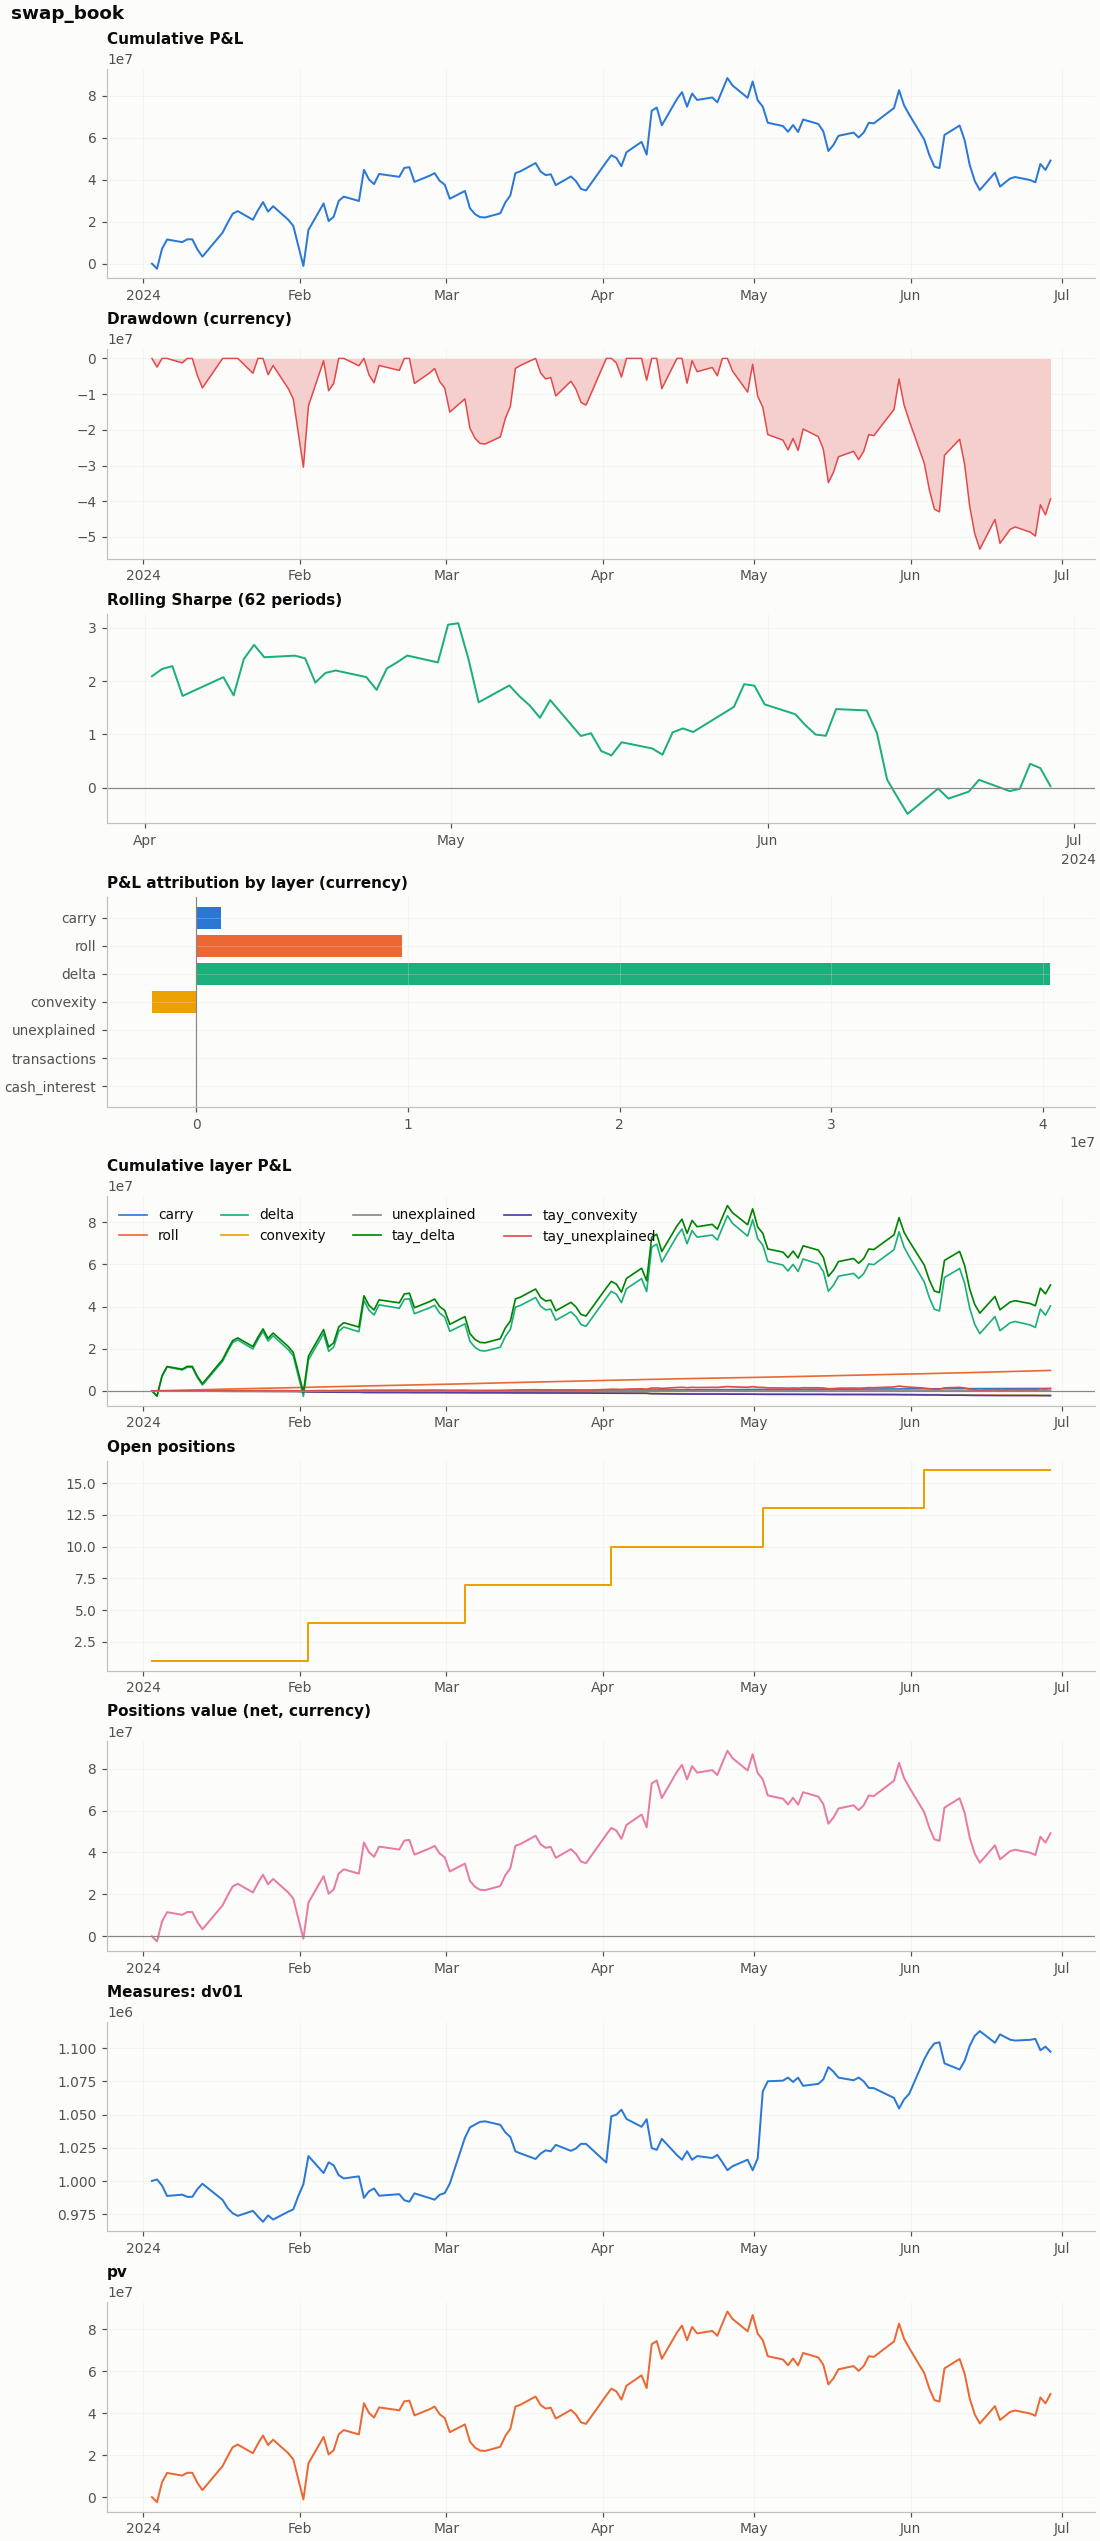

In [11]:
ts_out = res.tearsheet(OUT / "tearsheet", formats=["html", "png"], title="Monthly-rebalanced swap book")
print("written:", [str(p) for p in ts_out.paths])
display(Image(data=ts_out.figures["png"]))

**Summary statistics** (currency P&L on a zero-capital book), and the **P&L attribution by layer**. `unexplained` is what the library's layers do not account for; the engine's own
baseline decomposition (`tay_*`, computed by pricebt from the bound `dv01`, `gamma` and `rate`) is a second, library-independent view of the same total.

In [12]:
display(res.summary_stats().to_frame("value"))
display(res.attribution(by="layer"))
display(res.attribution(by="baseline"))

,value
start,2024-01-02 17:00:00-05:00
end,2024-06-28 17:00:00-04:00
basis,pnl
freq,session
periods_per_year,250.70
annualisation_source,grid
n_periods,124
total_pnl,"49,158,096.69"
peak_pnl,"88,515,930.33"
mean,"396,436.26"


,pnl,share
layer,,
carry,"1,178,005.40",0.02
roll,"9,725,153.85",0.20
delta,"40,355,275.70",0.82
convexity,"-2,103,294.95",-0.04
unexplained,"2,956.69",0.00
transactions,0.00,0.00
cash_interest,0.00,0.00
total,"49,158,096.69",1.00


,pnl,share
layer,,
tay_delta,"50,286,038.01",1.02
tay_convexity,"-2,224,399.73",-0.05
tay_unexplained,"1,096,458.41",0.02
transactions,-0.00,-0.00
cash_interest,0.00,0.00
total,"49,158,096.69",1.00


**Book dollar delta against the target over time.** The signals are read at the start of each point; the vertical lines are the monthly rebalances. Between rebalances the book
drifts as its swaps age and rates move; each rebalance brings the 10Y bucket back to the target.

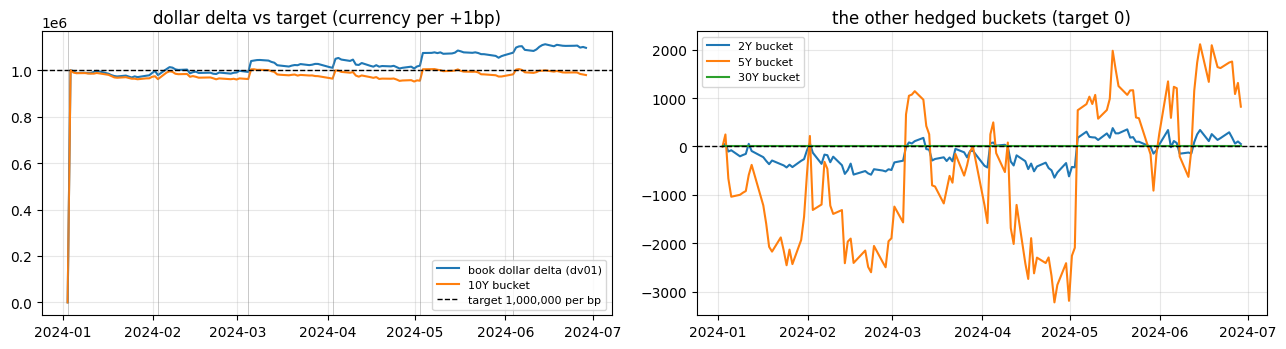

In [13]:
eq = res.record.equity
rebalances = sorted(set(res.trades["ts"]))
fig, axes = plt.subplots(1, 2, figsize=(13, 3.6))
ax = axes[0]
ax.plot(eq.index, eq["signal_book_dv01"], label="book dollar delta (dv01)", color="#1f77b4")
ax.plot(eq.index, eq["signal_ladder_10Y"], label="10Y bucket", color="#ff7f0e")
ax.axhline(TARGET["10Y"], color="k", ls="--", lw=1, label="target 1,000,000 per bp")
for t in rebalances:
    ax.axvline(t, color="grey", lw=0.6, alpha=0.5)
ax.set_title("dollar delta vs target (currency per +1bp)")
ax.legend(loc="lower right", fontsize=8)
ax = axes[1]
for t in ("2Y", "5Y", "30Y"):
    ax.plot(eq.index, eq[f"signal_ladder_{t}"], label=f"{t} bucket")
ax.axhline(0.0, color="k", ls="--", lw=1)
ax.set_title("the other hedged buckets (target 0)")
ax.legend(loc="best", fontsize=8)
plt.tight_layout()
plt.show()

**Before and after each rebalance.** The signals are read before a point's orders, so at a rebalance they show the drift the rebalance corrects; the recorded ladder of that row is taken
after the orders executed. **The ladder at selected dates** follows: at the first, a middle and the last rebalance, and at the end.

,10Y bucket before,10Y bucket after,book dv01 before,book dv01 after
2024-01-02,0.00,"1,000,000.00",0.00,"1,000,134.85"
2024-02-02,"962,262.97","1,000,000.00","979,683.46","1,018,864.12"
2024-03-04,"962,704.52","1,000,000.00","993,485.08","1,032,644.72"
2024-04-02,"964,492.40","1,000,000.00","1,011,219.10","1,048,743.65"
2024-05-02,"955,551.14","1,000,000.00","1,020,457.62","1,067,429.97"
2024-06-03,"983,050.89","1,000,000.00","1,076,428.63","1,091,693.48"


,2024-01-02,2024-04-02,2024-06-03,2024-06-28,target
3M,-0.00,690.16,753.98,"1,542.39",0.00
6M,0.00,"1,046.46","1,875.44","2,279.53",0.00
1Y,-0.00,"-1,312.46","-2,118.97","-2,393.35",0.00
2Y,-0.00,-0.00,0.00,51.47,0.00
3Y,-0.00,"-1,646.90","-1,611.79",-880.75,0.00
5Y,-0.00,-0.00,-0.00,822.42,0.00
7Y,-0.00,"49,966.54","92,796.26","115,887.27",0.00
10Y,"1,000,000.00","1,000,000.00","1,000,000.00","979,954.65","1,000,000.00"
15Y,-0.00,-1.89,-2.30,-2.67,0.00
20Y,-0.00,0.00,0.00,-0.00,0.00


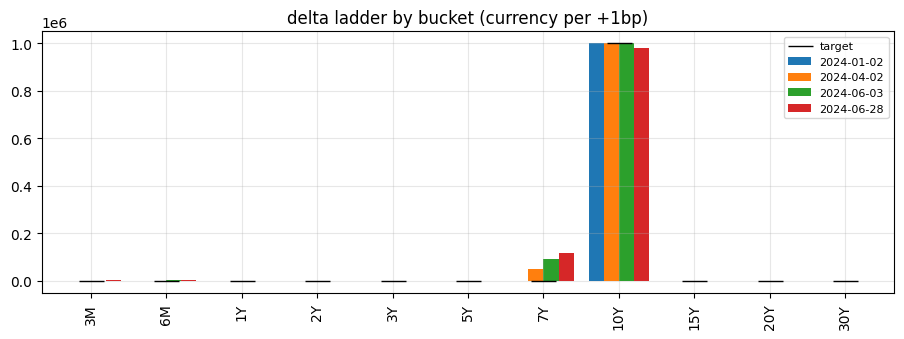

In [14]:
ladders = res.vectors["delta_ladder"]
before_after = pd.DataFrame({"10Y bucket before": [eq.loc[t, "signal_ladder_10Y"] for t in rebalances], "10Y bucket after": [ladders.loc[t, "10Y"] for t in rebalances],
                             "book dv01 before": [eq.loc[t, "signal_book_dv01"] for t in rebalances], "book dv01 after": [eq.loc[t, "measure_dv01"] for t in rebalances]},
                            index=[t.strftime("%Y-%m-%d") for t in rebalances])
display(before_after)
picked = [rebalances[0], rebalances[len(rebalances) // 2], rebalances[-1], ladders.index[-1]]
lad = ladders.loc[picked].T
lad.columns = [c.strftime("%Y-%m-%d") for c in lad.columns]
lad["target"] = pd.Series(TARGET).reindex(lad.index).fillna(0.0)
display(lad)
ax = lad.drop(columns="target").plot.bar(figsize=(11, 3.4), width=0.8)
ax.plot(range(len(lad)), lad["target"], "k_", markersize=18, label="target")
ax.set_title("delta ladder by bucket (currency per +1bp)")
ax.legend(fontsize=8)
plt.show()

**The trade ledger with the resolved terms.** An action supplied `maturity`, `side`, `notional` and `fixed_rate: par`; the library resolved the dates and the par rate at the fill pricer and
the engine recorded what it resolved (`term_*`), next to the spec's name.

In [15]:
cols = ["ts", "position", "kind", "quantity", "template", "instrument", "term_side", "term_effective", "term_maturity", "term_notional", "term_fixed_rate"]
display(res.trades[cols].head(12))
print(f"{len(res.trades)} trades; hedge legs used: {sorted(res.trades['template'].unique())}")

,ts,position,kind,quantity,template,instrument,term_side,term_effective,term_maturity,term_notional,term_fixed_rate
0,2024-01-02 17:00:00-05:00,P000001,open,"-1,195.38",hedge_10Y,usd_sofr_ois,receive,2024-01-04,2034-01-04,"1,000,000.00",3.53
1,2024-02-02 17:00:00-05:00,P000002,open,-0.68,hedge_2Y,usd_sofr_ois,receive,2024-02-06,2026-02-06,"1,000,000.00",4.24
2,2024-02-02 17:00:00-05:00,P000003,open,-2.90,hedge_5Y,usd_sofr_ois,receive,2024-02-06,2029-02-06,"1,000,000.00",3.74
3,2024-02-02 17:00:00-05:00,P000004,open,-45.44,hedge_10Y,usd_sofr_ois,receive,2024-02-06,2034-02-06,"1,000,000.00",3.67
4,2024-03-04 17:00:00-05:00,P000005,open,-1.55,hedge_2Y,usd_sofr_ois,receive,2024-03-06,2026-03-06,"1,000,000.00",4.52
5,2024-03-04 17:00:00-05:00,P000006,open,-3.50,hedge_5Y,usd_sofr_ois,receive,2024-03-06,2029-03-06,"1,000,000.00",3.97
6,2024-03-04 17:00:00-05:00,P000007,open,-45.36,hedge_10Y,usd_sofr_ois,receive,2024-03-06,2034-03-06,"1,000,000.00",3.84
7,2024-04-02 17:00:00-04:00,P000008,open,-2.29,hedge_2Y,usd_sofr_ois,receive,2024-04-04,2026-04-06,"1,000,000.00",4.61
8,2024-04-02 17:00:00-04:00,P000009,open,-3.54,hedge_5Y,usd_sofr_ois,receive,2024-04-04,2029-04-04,"1,000,000.00",4.11
9,2024-04-02 17:00:00-04:00,P000010,open,-43.49,hedge_10Y,usd_sofr_ois,receive,2024-04-04,2034-04-04,"1,000,000.00",3.99


16 trades; hedge legs used: ['hedge_10Y', 'hedge_2Y', 'hedge_5Y']


## 7. Assertions

These cells must pass. The tolerance of the second one is 1% of the total dv01 at the target buckets (here 1% of 1,000,000), the default of the specification.

In [16]:
rep = res.reconcile()
print(rep)
assert rep.ok, "reconcile() must be clean"

ReconcileReport(ok=True, checks=(Check(name='finite', passed=True, max_abs_error=0.0, n_violations=0, first_violation=None, severity='error', detail='missing=[] index_ok=True'), Check(name='identity', passed=True, max_abs_error=0.0, n_violations=0, first_violation=None, severity='error', detail=''), Check(name='step_pnl', passed=True, max_abs_error=0.0, n_violations=0, first_violation=None, severity='error', detail=''), Check(name='cash_rollforward', passed=True, max_abs_error=0.0, n_violations=0, first_violation=None, severity='error', detail=''), Check(name='tcost_rollforward', passed=True, max_abs_error=0.0, n_violations=0, first_violation=None, severity='error', detail=''), Check(name='positions_trades', passed=True, max_abs_error=0.0, n_violations=0, first_violation=None, severity='error', detail=''), Check(name='pnl_sum', passed=True, max_abs_error=0.0, n_violations=0, first_violation=None, severity='error', detail=''), Check(name='positions_value', passed=True, max_abs_error=0.0

In [17]:
TOL = 0.01 * sum(abs(v) for v in TARGET.values())
rows = []
for t in rebalances:
    lad_t = ladders.loc[t]
    dev = {b: float(lad_t.get(b, 0.0)) - TARGET.get(b, 0.0) for b in TARGET}
    rows.append({"rebalance": t.strftime("%Y-%m-%d"), **{f"{b} deviation": d for b, d in dev.items()}, "max |dev|": max(abs(d) for d in dev.values()), "within tolerance": max(abs(d) for d in dev.values()) <= TOL})
dev_table = pd.DataFrame(rows).set_index("rebalance")
display(dev_table)
print(f"tolerance {TOL:,.0f} per bp")
assert dev_table["within tolerance"].all(), "the target buckets must be within 1% of the target after each rebalance"

,10Y deviation,max |dev|,within tolerance
rebalance,,,
2024-01-02,-0.00,0.00,True
2024-02-02,0.00,0.00,True
2024-03-04,0.00,0.00,True
2024-04-02,0.00,0.00,True
2024-05-02,0.00,0.00,True
2024-06-03,0.00,0.00,True


tolerance 10,000 per bp


In [18]:
assert enabled_bars == 1, f"exactly one enabled progress bar, saw {enabled_bars}"
print("progress bars enabled during the run:", enabled_bars)

progress bars enabled during the run: 1


In [19]:
layers = res.attribution(by="layer")
modelled = [n for n in layers.index if n not in ("unexplained", "transactions", "cash_interest", "total")]
gross = layers.loc[modelled + ["unexplained"], "pnl"].abs().sum()
unexplained_share = float(abs(layers.loc["unexplained", "pnl"]) / gross)
UNEXPLAINED_THRESHOLD = 0.05  # the per-asset threshold of the layer conformance kit for a swap
print(f"unexplained share of the P&L attribution: {unexplained_share:.4%} (threshold {UNEXPLAINED_THRESHOLD:.0%})")
assert unexplained_share <= UNEXPLAINED_THRESHOLD

unexplained share of the P&L attribution: 0.0055% (threshold 5%)


In [20]:
assert res.n_errors == 0 and len(res.trades) > 0
assert set(res.trades["instrument"]) == {"usd_sofr_ois"}, "one instrument spec for every trade"
print("checks passed:", ", ".join(["reconcile clean", "target buckets within tolerance after every rebalance", "one enabled progress bar", "unexplained share bounded", "one spec"]))

checks passed: reconcile clean, target buckets within tolerance after every rebalance, one enabled progress bar, unexplained share bounded, one spec


## 8. The same base configuration under another library, tied out

A **stack** is an overlay that may set only an instrument's `factory` and `bind` and a pricer role's `wrap`. The strategy, the conventions block, the terms, the grid and the
market provider are the base, shared verbatim, so any difference between two runs is the library. The harness runs the base under each stack, first checks that the harness itself is
exact (the reference stack run twice must differ by exactly zero), then compares the runs level by level: L0 inputs, L1 marks, L2 measures, L3 layers, L4 portfolio.
The window is one month here to keep the notebook quick; the recorded tie-outs over the fixtures are in `results/tieout`.

In [21]:
from pricebt.tieout import run_tieout

TIE_END = "2024-02-29"
tie_base = copy.deepcopy(CONFIG)
tie_base["backtest"]["grid"] = {"start": START, "end": TIE_END, "freq": "1b"}
tie_base["backtest"]["progress"] = {"show": False}
tie_base["backtest"]["record_signals"] = []
tie_base["signals"] = {}
# The tolerances this strategy needs beyond the shipped defaults, each with its reason (they are measured in tasks/tolerance_ledger.yaml and are printed in the report):
tie_base["tieout"] = {"tolerances": {
    "L1.quantity": {"rel": 2e-3, "floor": 1e-2, "reason": "the hedge legs are sized by least squares from each stack's OWN measured ladder; the ladders agree to ~1e-4 per bucket and the legs that only soak up the residual amplify that to 1.1e-3 (measured)"},
    "L3.*": {"rel": 2e-3, "floor": 1.0, "reason": "layer AMOUNTS are per-unit layers times the held size, so they inherit the size difference above (1.14e-3 measured); the per-unit rows (`<layer>/unit`) isolate the library and pass the shipped tolerances"},
    "L3.unexplained": {"rel": 1.5e-2, "floor": 1.0, "reason": "the QuantLib adapter differences its directional derivatives with step h = 0.1, so its remainder is (1 - h^2) = 0.99 times the true one (verified); 1.5e-2 is 1.5 x h^2"},
    "L4.trade_cash": {"rel": 1e-6, "floor": 1.0, "reason": "entry cash is -quantity x entry pv and a par swap's entry pv is 1e-10 per unit: 1.3e-7 currency on 1195 units (measured)"},
}}
STACKS = {
    "rateslib": {"instruments": {"usd_sofr_ois": {"factory": "pricebt.contrib.rateslib:swap"}}, "market": {"pricers": {"primary": {"wrap": "pricebt.contrib.rateslib:wrap"}}}},
    "quantlib": {"instruments": {"usd_sofr_ois": {"factory": "pricebt.contrib.quantlib:swap"}}, "market": {"pricers": {"primary": {"wrap": "pricebt.contrib.quantlib:wrap"}}}},
    "reference": {"instruments": {"usd_sofr_ois": {"factory": "pricebt.testing.refstack:swap"}}, "market": {"pricers": {"primary": {"wrap": "pricebt.testing.refstack:wrap"}}}},
}
tie = run_tieout(tie_base, {name: [overlay] for name, overlay in STACKS.items()}, reference="reference", selftest=True, out=OUT / "tieout",
                 audit_measures=("dv01", "gamma", "rate", "delta_ladder"))
print("harness self-test:", tie.header["selftest"], "| base config shared by all stacks:", len(set(tie.header["config_hash"].values())) >= 1, "| base hash:", tie.header["base_hash"][:12])

harness self-test: passed | base config shared by all stacks: True | base hash: c0b961b40dad


In [22]:
for name, rep in tie.reports.items():
    f = rep.frame()
    print(f"\n{name}: {'PASS' if rep.passed else 'FAIL'}: {len(f)} quantities, by status {f['status'].value_counts().to_dict()}")
    display(f.loc[f["status"] != "exact", ["level", "quantity", "asset_class", "n", "max_abs", "max_rel", "tol_rel", "tol_floor", "status"]].head(40))


reference_vs_rateslib: PASS: 52 quantities, by status {'noise': 40, 'exact': 12}


,level,quantity,asset_class,n,max_abs,max_rel,tol_rel,tol_floor,status
4,L1,quantity,swap,98,0.00,0.00,0.00,0.01,noise
5,L1,pv,swap,98,0.00,0.00,0.00,1.00,noise
8,L2,delta_ladder.10Y,swap,98,0.01,0.00,0.00,100.00,noise
9,L2,delta_ladder.15Y,swap,98,0.00,0.00,0.00,100.00,noise
10,L2,delta_ladder.1Y,swap,98,0.00,0.00,0.00,100.00,noise
11,L2,delta_ladder.20Y,swap,98,0.00,0.00,0.00,100.00,noise
12,L2,delta_ladder.2Y,swap,98,0.03,0.00,0.00,100.00,noise
13,L2,delta_ladder.30Y,swap,98,0.00,0.00,0.00,100.00,noise
14,L2,delta_ladder.3M,swap,98,0.00,0.00,0.00,100.00,noise
15,L2,delta_ladder.3Y,swap,98,0.02,0.00,0.00,100.00,noise



reference_vs_quantlib: PASS: 52 quantities, by status {'noise': 39, 'exact': 13}


,level,quantity,asset_class,n,max_abs,max_rel,tol_rel,tol_floor,status
4,L1,quantity,swap,98,0.00,0.00,0.00,0.01,noise
5,L1,pv,swap,98,0.00,0.00,0.00,1.00,noise
8,L2,delta_ladder.10Y,swap,98,0.01,0.00,0.00,100.00,noise
9,L2,delta_ladder.15Y,swap,98,0.00,0.00,0.00,100.00,noise
10,L2,delta_ladder.1Y,swap,98,0.00,0.00,0.00,100.00,noise
11,L2,delta_ladder.20Y,swap,98,0.00,0.00,0.00,100.00,noise
12,L2,delta_ladder.2Y,swap,98,0.03,0.00,0.00,100.00,noise
14,L2,delta_ladder.3M,swap,98,0.00,0.00,0.00,100.00,noise
15,L2,delta_ladder.3Y,swap,98,0.02,0.00,0.00,100.00,noise
16,L2,delta_ladder.5Y,swap,98,0.02,0.00,0.00,100.00,noise


Reading the table: `exact` means bit-identical, `noise` a difference within the declared tolerance, `expected` a documented difference of *definition* (for example a layer that two
libraries decompose differently), `exceeds` a failure, and `input` says an L0 difference (a different resolved date or par rate) already explains it. Tolerances are declared per level
and never widened to make a run pass without a written reason (`tasks/tolerance_ledger.yaml`).

In [23]:
# The assertions of this section: the harness is exact against itself, all three stacks consumed identical inputs, no difference is unexplained, and every declared tolerance carries its reason.
assert str(tie.header["selftest"]).startswith("passed"), tie.header["selftest"]
assert tie.passed, [n for n, r in tie.reports.items() if not r.passed]
for name, rep in tie.reports.items():
    f = rep.frame()
    assert (f.loc[f["level"] == "L0", "status"] == "exact").all(), f"{name}: the inputs differ"
    assert not f["status"].isin(["exceeds", "input", "structure"]).any(), name
declared = tie_base["tieout"]["tolerances"]
assert declared and all(v["reason"] for v in declared.values())
print("tie-out checks passed:", ", ".join(["harness self-test exact", "identical snapshots and terms at L0", "no exceedance, input or structure difference", "every declared tolerance has a reason"]))

tie-out checks passed: harness self-test exact, identical snapshots and terms at L0, no exceedance, input or structure difference, every declared tolerance has a reason
